In [16]:
import warnings

import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_diabetes
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

In [17]:
X, y = load_diabetes(return_X_y=True)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (442, 10)
y shape: (442,)


In [18]:
# Train 70% | Validation 15% | Test 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (309, 10)
X_val shape: (66, 10)
X_test shape: (67, 10)


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [20]:
METRIC = "mae"


def create_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(10,), name="input"),
            layers.Dense(64, activation="relu", name="hidden1"),
            layers.Dense(32, activation="relu", name="hidden2"),
            layers.Dense(16, activation="relu", name="hidden3"),
            layers.Dense(1, activation="linear", name="output"),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[METRIC],
    )
    return model


model = create_model()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
def create_early_stopping():
    return EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )


def create_reduce_lr():
    return ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )


history = model.fit(
    X_train_scaled,
    y_train,
    batch_size=64,
    epochs=50,
    validation_data=(X_val_scaled, y_val),
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 29777.5723 - mae: 153.7390 - val_loss: 26766.7246 - val_mae: 147.1433 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29707.0391 - mae: 153.4988 - val_loss: 26697.5586 - val_mae: 146.8875 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29632.6934 - mae: 153.2450 - val_loss: 26619.9355 - val_mae: 146.6031 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29546.8730 - mae: 152.9558 - val_loss: 26524.9043 - val_mae: 146.2640 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29441.5859 - mae: 152.6060 - val_loss: 26405.7344 - val_mae: 145.8444 - learning_rate: 0.0010
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29309.9805 - mae: 152.1725 - val_loss: 26256.9727 - val_mae: 145.3250 - learning_rate: 0.0010
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29143.7637 - mae: 151.6301 - val_loss

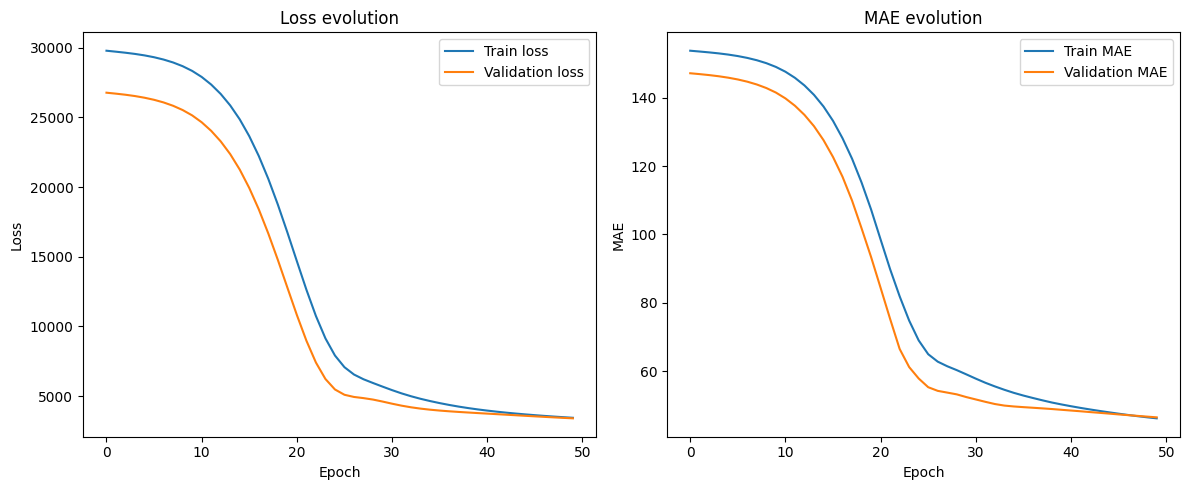

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(history.history["loss"], label="Train loss")
ax1.plot(history.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Metric
ax2.plot(history.history[METRIC], label=f"Train {METRIC.upper()}")
ax2.plot(history.history[f"val_{METRIC}"], label=f"Validation {METRIC.upper()}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel(f"{METRIC.upper()}")
ax2.set_title(f"{METRIC.upper()} evolution")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test_scaled)

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2:  ", r2_score(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
MAE:  51.36090076503469
RMSE: 65.84321314089144
MSE:  4335.328716716858
R2:   0.23646617728903596
